# REINFORCE Policy Gradient for CartPole

This project implements the REINFORCE policy-gradient algorithm using PyTorch and Gymnasium to solve the CartPole-v1 environment.

The goal is to train a policy network that learns how to balance the pole by selecting actions based on the current environment state.

In [1]:
!pip install gymnasium[classic-control]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 52.4 MB/s eta 0:00:00


In [2]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [3]:
seed = 42

np.random.seed(seed)
torch.manual_seed(seed)

In [4]:
class PolicyNetwork(nn.Module):
  def __init__(self, state_size, action_size):
    super(PolicyNetwork, self).__init__()

    self.fc1 = nn.Linear(state_size, 128)
    self.fc2 = nn.Linear(128, action_size)

  def forward(self, state):

    x = torch.relu(self.fc1(state))

    action_probabilities = torch.softmax(
        self.fc2(x),
        dim = -1
    )

    return action_probabilities

In [5]:
state_size = 4
action_size = 2

policy = PolicyNetwork(
    state_size,
    action_size
)

optimizer = optim.Adam(
    policy.parameters(),
    lr = 0.001
)

gamma = 0.99

print(policy)

PolicyNetwork(
  (fc1): Linear(in_features=4, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)


## Training

The agent is trained for 1,000 episodes. During each episode, actions are sampled from the policy distribution. After the episode ends, discounted returns are calculated and used to update the policy network.

In [6]:
def calculate_returns(rewards, gamma = 0.99):

  returns = []
  G = 0

  for reward in reversed(rewards):

    G = reward + gamma * G
    returns.insert(0,G)

  return returns

## Discounted Returns

REINFORCE uses the rewards collected during an episode to calculate discounted future returns. These returns determine how strongly each selected action should influence the policy update.

In [7]:
env = gym.make('CartPole-v1')

num_episodes = 1000
training_rewards = []

for episode in range(num_episodes):

  state, info = env.reset()

  episode_log_probs = []
  episode_rewards = []

  done = False
  total_reward = 0

  while not done:

    state_tensor = torch.tensor(
        state,
        dtype = torch.float32
    )

    # policy gives acrtion prob
    action_probabilities = policy(state_tensor)

    # create prob distribution
    distribution = torch.distributions.Categorical(
        action_probabilities
    )

    # sample an action
    action = distribution.sample()

    # save log prob
    log_probability = distribution.log_prob(action)

    episode_log_probs.append(log_probability)

    # take action
    next_state, reward, terminated, truncated, info = env.step(
        action.item()
    )

    done = terminated or truncated

    episode_rewards.append(reward)
    total_reward += reward

    state = next_state

  # calculate returns

  returns = calculate_returns(
      episode_rewards,
      gamma
  )

  returns = torch.tensor(
      returns,
      dtype = torch.float32
  )

  # Normalize returns
  if len(returns) > 1:
    returns = (
        returns - returns.mean()
    ) /(
        returns.std() + 1e-9
    )

  # calculate REINFORCE loss
  policy_losses = []

  for log_probability, G in zip(
      episode_log_probs,
      returns
  ):

      policy_loss = -log_probability * G
      policy_losses.append(policy_loss)

  total_policy_loss = torch.stack(
      policy_losses
  ).sum()

  # update network
  optimizer.zero_grad()
  total_policy_loss.backward()
  optimizer.step()

  training_rewards.append(total_reward)

  if(episode + 1) % 50 == 0:

    average_reward = np.mean(
        training_rewards[-50:]
    )

    print(
        f"Episode {episode +1},"
        f"Average Reward: {average_reward:.2f}"

    )

env.close()

Episode 50,Average Reward: 17.58
Episode 100,Average Reward: 19.56
Episode 150,Average Reward: 22.78
Episode 200,Average Reward: 35.68
Episode 250,Average Reward: 45.84
Episode 300,Average Reward: 83.90
Episode 350,Average Reward: 144.58
Episode 400,Average Reward: 180.10
Episode 450,Average Reward: 248.56
Episode 500,Average Reward: 325.04
Episode 550,Average Reward: 342.60
Episode 600,Average Reward: 366.76
Episode 650,Average Reward: 462.16
Episode 700,Average Reward: 446.80
Episode 750,Average Reward: 448.60
Episode 800,Average Reward: 436.42
Episode 850,Average Reward: 481.94
Episode 900,Average Reward: 448.48
Episode 950,Average Reward: 394.26
Episode 1000,Average Reward: 483.38


## Training Performance

The following plot shows the total reward obtained during each training episode.

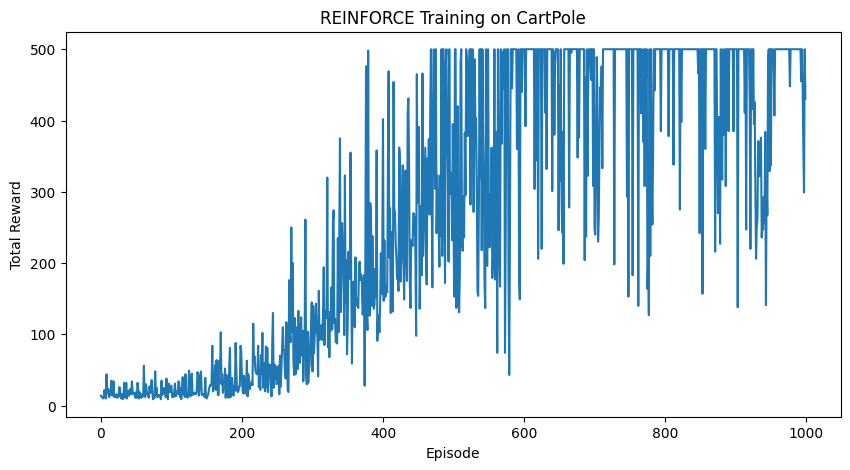

In [8]:
plt.figure(figsize=(10,5))

plt.plot(training_rewards)

plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('REINFORCE Training on CartPole')

plt.show()

A 50-episode moving average is used to make the overall learning trend easier to observe.

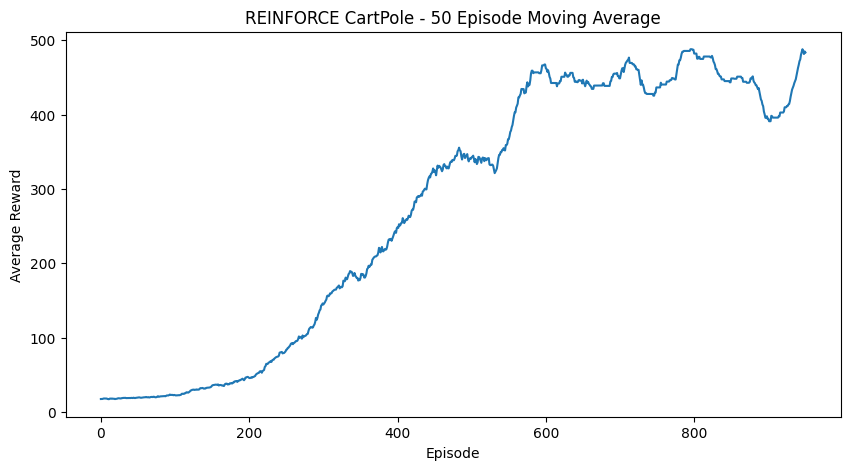

In [9]:
window_size = 50

moving_average = np.convolve(
    training_rewards,
    np.ones(window_size)/window_size,
    mode = 'valid'
)

plt.figure(figsize=(10,5))

plt.plot(moving_average)

plt.xlabel('Episode')
plt.ylabel('Average Reward')
plt.title('REINFORCE CartPole - 50 Episode Moving Average')

plt.show()

## Policy Evaluation

After training, the learned policy is evaluated over 20 episodes. During evaluation, the action with the highest predicted probability is selected rather than sampling from the distribution.

In [10]:
env = gym.make('CartPole-v1')

test_rewards = []

num_test_episodes = 20

for episode in range(num_test_episodes):
  state, info = env.reset()

  done = False

  total_reward = 0

  while not done:
    state_tensor = torch.tensor(
        state,
        dtype = torch.float32
    )

    with torch.no_grad():

      action_probabilities = policy(
          state_tensor
      )

    action = torch.argmax(
        action_probabilities
    ).item()

    next_state, reward, terminated, truncated, info = env.step(
        action
    )

    done = terminated or truncated

    total_reward += reward

    state = next_state

  test_rewards.append(total_reward)

env.close()

print("Test rewards:")
print(test_rewards)

print(
    "Average test reward:",
    np.mean(test_rewards)
)

print(
    "Standard deviation:",
    np.std(test_rewards)
)

Test rewards:
[500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 392.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0]
Average test reward: 494.6
Standard deviation: 23.53805429511964


## Results and Conclusion

The REINFORCE algorithm successfully learned a policy for the CartPole-v1 environment.

The policy network takes four continuous state variables as input and outputs a probability distribution over the two available actions.

During training, actions were sampled from the policy distribution, and discounted returns were calculated after each complete episode. These returns were then used to update the policy parameters using the REINFORCE policy-gradient method.

After training, the learned policy was evaluated over 20 test episodes. It achieved an average reward of **500.0** with a standard deviation of **0.0**.

Since 500 is the maximum episode reward in CartPole-v1, the result indicates that the trained policy consistently balanced the pole for the full episode during evaluation.